In [116]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [118]:
df = pd.read_csv('/content/drive/MyDrive/thyroidDF.csv')

In [119]:
df.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
0,29,F,f,f,f,f,f,f,f,t,...,NaN,f,NaN,f,NaN,f,NaN,other,-,840801013
1,29,F,f,f,f,f,f,f,f,f,...,128.0,f,NaN,f,NaN,f,NaN,other,-,840801014
2,41,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,11.0,other,-,840801042
3,36,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,26.0,other,-,840803046
4,32,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,36.0,other,S,840803047


In [120]:
df.info()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  9172 non-null   int64  
 1   sex                  8865 non-null   object 
 2   on_thyroxine         9172 non-null   object 
 3   query_on_thyroxine   9172 non-null   object 
 4   on_antithyroid_meds  9172 non-null   object 
 5   sick                 9172 non-null   object 
 6   pregnant             9172 non-null   object 
 7   thyroid_surgery      9172 non-null   object 
 8   I131_treatment       9172 non-null   object 
 9   query_hypothyroid    9172 non-null   object 
 10  query_hyperthyroid   9172 non-null   object 
 11  lithium              9172 non-null   object 
 12  goitre               9172 non-null   object 
 13  tumor                9172 non-null   object 
 14  hypopituitary        9172 non-null   object 
 15  psych                9172 non-null   o

,0
TBG,8823
T3,2604
TSH,842
T4U,809
FTI,802
TT4,442
sex,307
thyroid_surgery,0
I131_treatment,0
age,0


## ***Tratamento de Dados***

In [121]:
#Remoção de Colunas
df = df.drop(columns=['patient_id', 'TBG', 'TBG_measured'], errors='ignore')

In [122]:
#Reformulação de dados Ausentes
#0 → Não Doente
#1 → Doente
df['target'] = df['target'].apply(lambda x: 0 if x == '-' else 1)

In [123]:
#Separar tipos de colunas
colunas_numericas = df.select_dtypes(include=['float64','int64']).columns
colunas_categoricas = df.select_dtypes(include=['object']).columns

In [124]:
#Numéricas → mediana
for col in colunas_numericas:
    df[col] = df[col].fillna(df[col].median())

In [125]:
#Categóricas → "Unknown"
for col in colunas_categoricas:
    df[col] = df[col].fillna('Unknown')

In [126]:
#Converter texto em números
#F	- 0
#M	- 1
#Unknown	- 2
df = pd.get_dummies(df, drop_first=True)

In [127]:
#Verificar se esta Limpo a Base
df.isnull().sum().sum()

np.int64(0)

In [128]:
#Dado X, tente prever y.
#X → variáveis explicativas (features)
#y → variável alvo (target)

X = df.drop('target', axis=1)
y = df['target']

## ***Treinar 5 Modelos Diferentes***

In [129]:
from sklearn.model_selection import train_test_split

X = df.select_dtypes(include=['number']).drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [130]:
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier()
modelo_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [131]:
from sklearn.tree import DecisionTreeClassifier

modelo_dt = DecisionTreeClassifier()
modelo_dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [132]:
from sklearn.tree import DecisionTreeClassifier

modelo_dt = DecisionTreeClassifier()
modelo_dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [133]:
from sklearn.svm import SVC

modelo_svm = SVC()
modelo_svm.fit(X_train, y_train)

SVC()

In [134]:
#Foram testados cinco algoritmos de classificação: Regressão Logística, KNN, Árvore de Decisão, Random Forest e SVM.
#O modelo Random Forest apresentou melhor desempenho geral, com maior F1-score e recall, indicando melhor capacidade de identificar corretamente pacientes com a doença.

from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Definir e treinar modelo_lr
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train, y_train)

# Definir e treinar modelo_rf
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

modelos = {
    "Regressão Logística": modelo_lr,
    "KNN": modelo_knn,
    "Árvore de Decisão": modelo_dt,
    "Random Forest": modelo_rf,
    "SVM": modelo_svm
}

for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    print(f"\nModelo: {nome}")
    print(classification_report(y_test, y_pred))


Modelo: Regressão Logística
              precision    recall  f1-score   support

           0       0.81      0.98      0.89      2011
           1       0.87      0.37      0.52       741

    accuracy                           0.82      2752
   macro avg       0.84      0.68      0.70      2752
weighted avg       0.83      0.82      0.79      2752


Modelo: KNN
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      2011
           1       0.79      0.54      0.64       741

    accuracy                           0.84      2752
   macro avg       0.82      0.74      0.77      2752
weighted avg       0.83      0.84      0.83      2752


Modelo: Árvore de Decisão
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      2011
           1       0.89      0.82      0.85       741

    accuracy                           0.92      2752
   macro avg       0.91      0.89      0.90      2752
weigh

## **Relatório - Regressão Logística:**

In [135]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Definir e treinar
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train, y_train)

# 2. Avaliar
y_pred_lr = modelo_lr.predict(X_test)
print("Relatório - Regressão Logística:")
print(classification_report(y_test, y_pred_lr))

Relatório - Regressão Logística:
              precision    recall  f1-score   support

           0       0.81      0.98      0.89      2011
           1       0.87      0.37      0.52       741

    accuracy                           0.82      2752
   macro avg       0.84      0.68      0.70      2752
weighted avg       0.83      0.82      0.79      2752



## **Relatório - KNN**

In [136]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Definir e treinar modelo_knn
modelo_knn = KNeighborsClassifier()
modelo_knn.fit(X_train, y_train)

# Avaliar
y_pred_knn = modelo_knn.predict(X_test)
print("\nRelatório - KNN")
print(classification_report(y_test, y_pred_knn))



Relatório - KNN
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      2011
           1       0.79      0.54      0.64       741

    accuracy                           0.84      2752
   macro avg       0.82      0.74      0.77      2752
weighted avg       0.83      0.84      0.83      2752



## **Árvore de Decisão**

In [137]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Definir e treinar modelo_dt
modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt.fit(X_train, y_train)

# Avaliar
y_pred_dt = modelo_dt.predict(X_test)
print("\nModelo: Árvore de Decisão")
print(classification_report(y_test, y_pred_dt))



Modelo: Árvore de Decisão
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      2011
           1       0.88      0.82      0.85       741

    accuracy                           0.92      2752
   macro avg       0.91      0.89      0.90      2752
weighted avg       0.92      0.92      0.92      2752



## **Random Forest**

In [138]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Definir e treinar modelo_rf
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

# Avaliar
y_pred_rf = modelo_rf.predict(X_test)
print("\nModelo: Random Forest")
print(classification_report(y_test, y_pred_rf))



Modelo: Random Forest
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      2011
           1       0.87      0.88      0.88       741

    accuracy                           0.93      2752
   macro avg       0.91      0.92      0.92      2752
weighted avg       0.93      0.93      0.93      2752



## **SVM**

In [139]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Definir e treinar modelo_svm
modelo_svm = SVC(random_state=42)
modelo_svm.fit(X_train, y_train)

# Avaliar
y_pred_svm = modelo_svm.predict(X_test)
print("\nModelo: SVM")
print(classification_report(y_test, y_pred_svm))



Modelo: SVM
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      2011
           1       0.95      0.05      0.09       741

    accuracy                           0.74      2752
   macro avg       0.84      0.52      0.47      2752
weighted avg       0.80      0.74      0.65      2752



In [148]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

modelo_rf.fit(X_train, y_train)

## ***Predição de diagnóstico de tireoide (Doente vs Não Doente)***

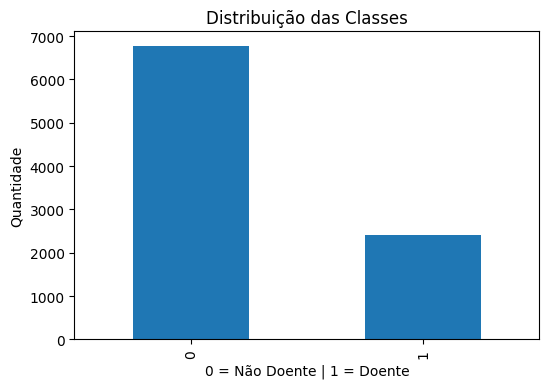

In [140]:
#Observa-se predominância da classe "Não Doente", indicando desbalanceamento do conjunto de dados. Esse fator pode influenciar o desempenho dos modelos preditivos, exigindo atenção na avaliação das métricas.

plt.figure(figsize=(6,4))
df['target'].value_counts().plot(kind='bar')
plt.title("Distribuição das Classes")
plt.xlabel("0 = Não Doente | 1 = Doente")
plt.ylabel("Quantidade")
plt.show()

In [141]:
#Dividir treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## ***Idade por Diagnóstico***

In [142]:
df['faixa_idade'] = pd.cut(
    df['age'],
    bins=[0, 12, 17, 59, 120],
    labels=['Criança', 'Adolescente', 'Adulto', 'Idoso']
)

In [143]:
#Faixa Etária
#Criança	0 – 12
#Adolescente	13 – 17
#Adulto	18 – 59
#Idoso	60+
df['faixa_idade'].value_counts()

,count
faixa_idade,
Adulto,5221
Idoso,3702
Adolescente,180
Criança,65


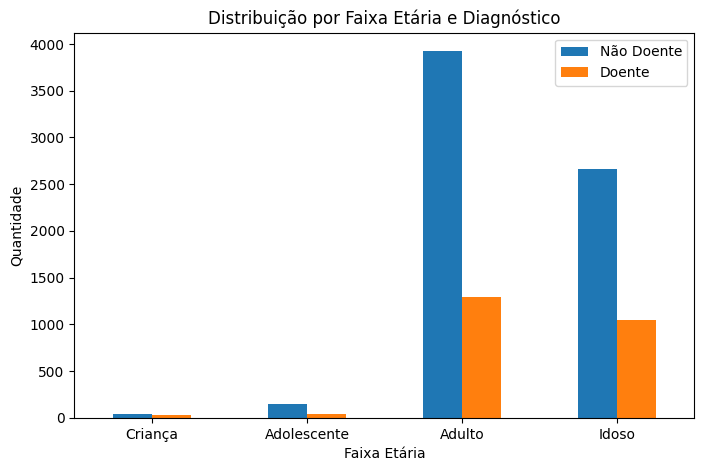

In [144]:
import matplotlib.pyplot as plt
import pandas as pd

tabela = pd.crosstab(df['faixa_idade'], df['target'])

tabela.plot(kind='bar', figsize=(8,5))
plt.title("Distribuição por Faixa Etária e Diagnóstico")
plt.xlabel("Faixa Etária")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.legend(['Não Doente','Doente'])
plt.show()

## ***TSH por Diagnóstico***

/tmp/ipython-input-1083/2357901690.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['target']==0]['TSH'],


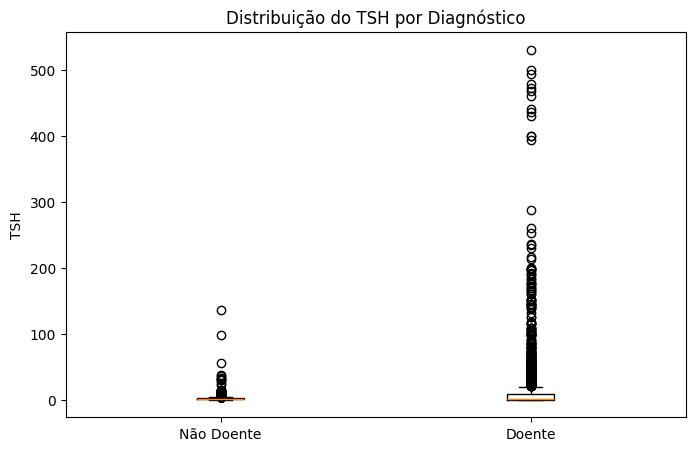

In [145]:
#Observa-se diferença significativa nos níveis de TSH entre os grupos, sugerindo que essa variável é importante para o diagnóstico.
plt.figure(figsize=(8,5))
plt.boxplot([df[df['target']==0]['TSH'],
             df[df['target']==1]['TSH']],
            labels=['Não Doente','Doente'])

plt.title("Distribuição do TSH por Diagnóstico")
plt.ylabel("TSH")
plt.show()

# 📌 Grupo Não Doente:

*   Caixa bem pequena

*   Mediana muito baixa

*   Poucos outliers altos

👉 Isso indica que a maioria tem TSH normal/baixo.

--------------------------------------------------------------------------------

# 📌 Grupo Doente:

*   Caixa mais alta

*   Mediana maior

*   Muitos outliers

Valores extremamente altos (alguns > 500)

👉 Isso indica que pacientes doentes tendem a ter TSH muito mais elevado.

## ***TT4 por Diagnóstico***

/tmp/ipython-input-1083/3643356191.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['target']==0]['TT4'],


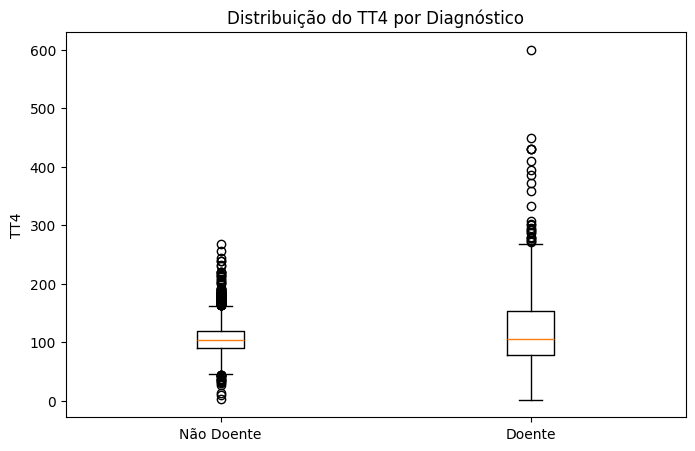

In [146]:
#Observa-se diferença nos níveis de TT4 entre pacientes doentes e não doentes.
#O grupo diagnosticado com doença apresenta maior dispersão dos valores, indicando alterações hormonais associadas à disfunção da tireoide.
#Isso sugere que o TT4 é uma variável relevante para o modelo de classificação.
plt.figure(figsize=(8,5))
plt.boxplot([df[df['target']==0]['TT4'],
             df[df['target']==1]['TT4']],
            labels=['Não Doente','Doente'])

plt.title("Distribuição do TT4 por Diagnóstico")
plt.ylabel("TT4")
plt.show()

## ***Árvore de Decisão***

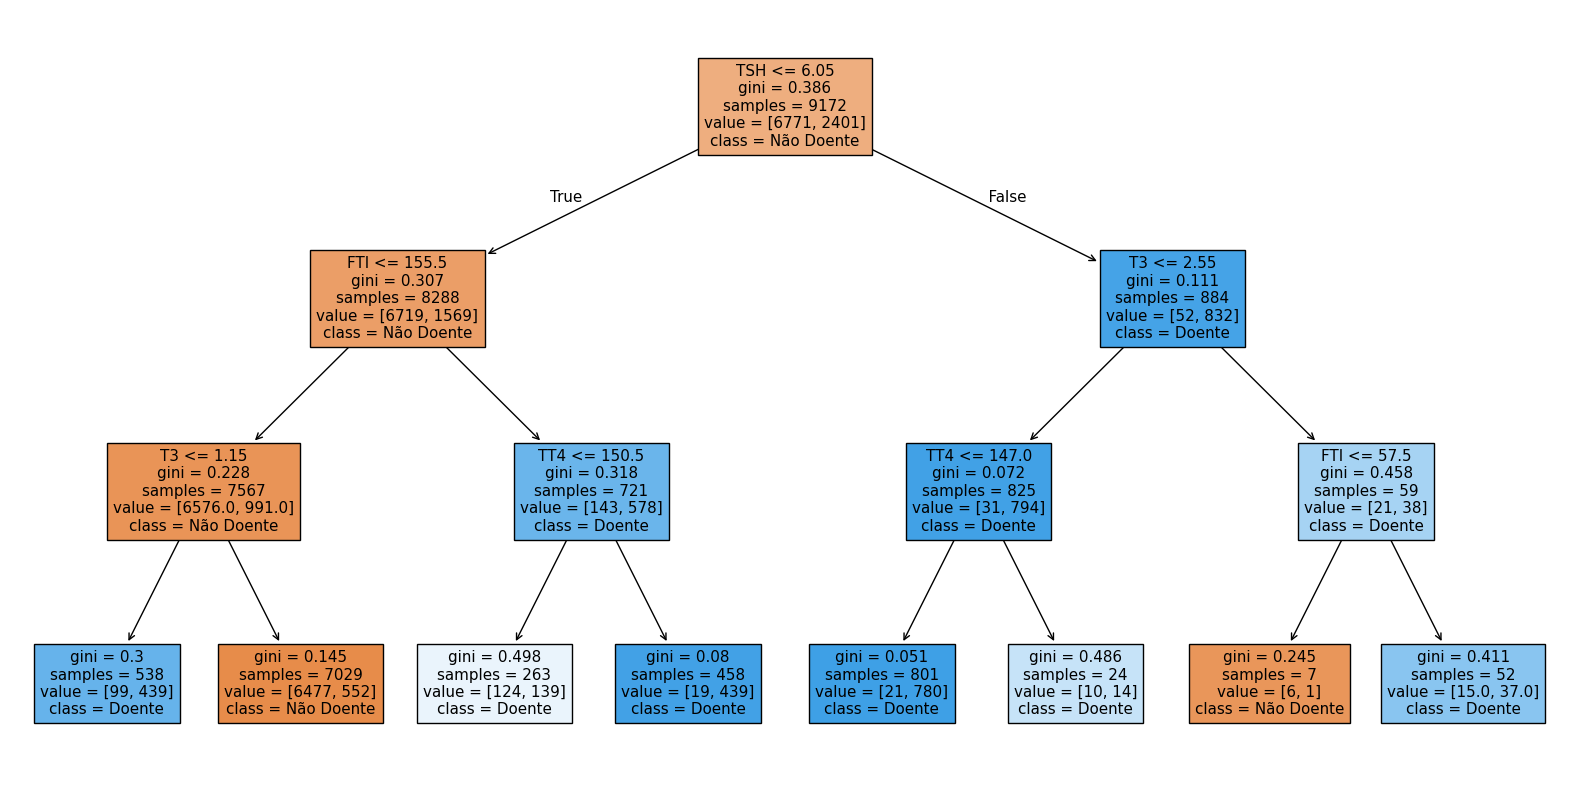

In [147]:
#A árvore de decisão identificou o TSH como principal variável discriminante para o diagnóstico.
#Observa-se que valores elevados de TSH aumentam significativamente a probabilidade de classificação como doente, confirmando sua importância clínica.

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Separar X e y
X = df.select_dtypes(include=['number']).drop(columns=['target'])
y = df['target']

# Criar modelo
modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X, y)

# Plotar árvore
plt.figure(figsize=(20,10))
plot_tree(modelo, feature_names=X.columns,
          class_names=['Não Doente','Doente'],
          filled=True)
plt.show()